# Task 6: Text Classification with Naive Bayes

**Dataset:** 20 Newsgroups (sklearn built-in) — subset of 4 categories  
**Goal:** Classify news articles into topics using a Multinomial Naive Bayes model with TF-IDF features.

Naive Bayes works well for text because it treats each word independently and scales nicely with vocabulary size. Despite being 'naive', it's surprisingly hard to beat on short text classification.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import shutil
import os

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# pick 4 categories to keep the task focused
categories = [
    'sci.space',
    'rec.sport.baseball',
    'talk.politics.guns',
    'comp.graphics'
]

# use a local data directory so we avoid conflicts with any system-level cache
data_home = os.path.join(os.getcwd(), 'data_20news')
# wipe any partial/stale download to prevent OSError on re-runs
news_cache = os.path.join(data_home, '20news_home')
if os.path.exists(news_cache):
    shutil.rmtree(news_cache)

train_data = fetch_20newsgroups(subset='train', categories=categories,
                                 remove=('headers', 'footers', 'quotes'),
                                 data_home=data_home)
test_data  = fetch_20newsgroups(subset='test',  categories=categories,
                                 remove=('headers', 'footers', 'quotes'),
                                 data_home=data_home)

print(f"Train samples: {len(train_data.data)}")
print(f"Test  samples: {len(test_data.data)}")
print(f"Categories: {train_data.target_names}")

Train samples: 2320
Test  samples: 1544
Categories: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.guns']


## Text Preprocessing

TF-IDF handles most of the heavy lifting, but a quick clean helps.

In [2]:
def clean_text(text):
    # lowercase
    text = text.lower()
    # remove numbers and punctuation
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    # collapse extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

X_train_raw = [clean_text(t) for t in train_data.data]
X_test_raw  = [clean_text(t) for t in test_data.data]
y_train = train_data.target
y_test  = test_data.target

# peek at a sample
print("Sample (cleaned):")
print(X_train_raw[0][:300])
print(f"\nLabel: {train_data.target_names[y_train[0]]}")

Sample (cleaned):
what about guns with nonlethal bullets like rubber or plastic bullets would those work very well in stopping an attack

Label: talk.politics.guns


## TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) gives higher weight to words that are frequent in a document but rare across documents — these are the informative words.

In [3]:
# max_features limits vocab size, min_df=2 drops very rare words
vectorizer = TfidfVectorizer(max_features=15000, min_df=2, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_test_tfidf  = vectorizer.transform(X_test_raw)  # only transform, not fit

print(f"Train matrix: {X_train_tfidf.shape}")
print(f"Test  matrix: {X_test_tfidf.shape}")

Train matrix: (2320, 11814)
Test  matrix: (1544, 11814)


## Train Naive Bayes Classifier

In [4]:
# alpha is the Laplace smoothing parameter
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)

y_pred = nb.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc*100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=train_data.target_names))

Accuracy: 89.25%

                    precision    recall  f1-score   support

     comp.graphics       0.91      0.91      0.91       389
rec.sport.baseball       0.86      0.93      0.90       397
         sci.space       0.90      0.85      0.87       394
talk.politics.guns       0.89      0.88      0.89       364

          accuracy                           0.89      1544
         macro avg       0.89      0.89      0.89      1544
      weighted avg       0.89      0.89      0.89      1544



## Confusion Matrix

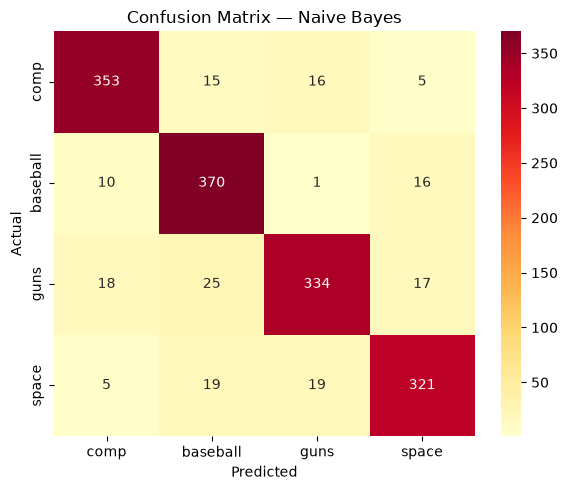

In [5]:
cm = confusion_matrix(y_test, y_pred)
short_names = ['comp', 'baseball', 'guns', 'space']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=short_names, yticklabels=short_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Naive Bayes')
plt.tight_layout()
plt.savefig('task6_confusion.png', dpi=100)
plt.show()

## Top Predictive Words per Category

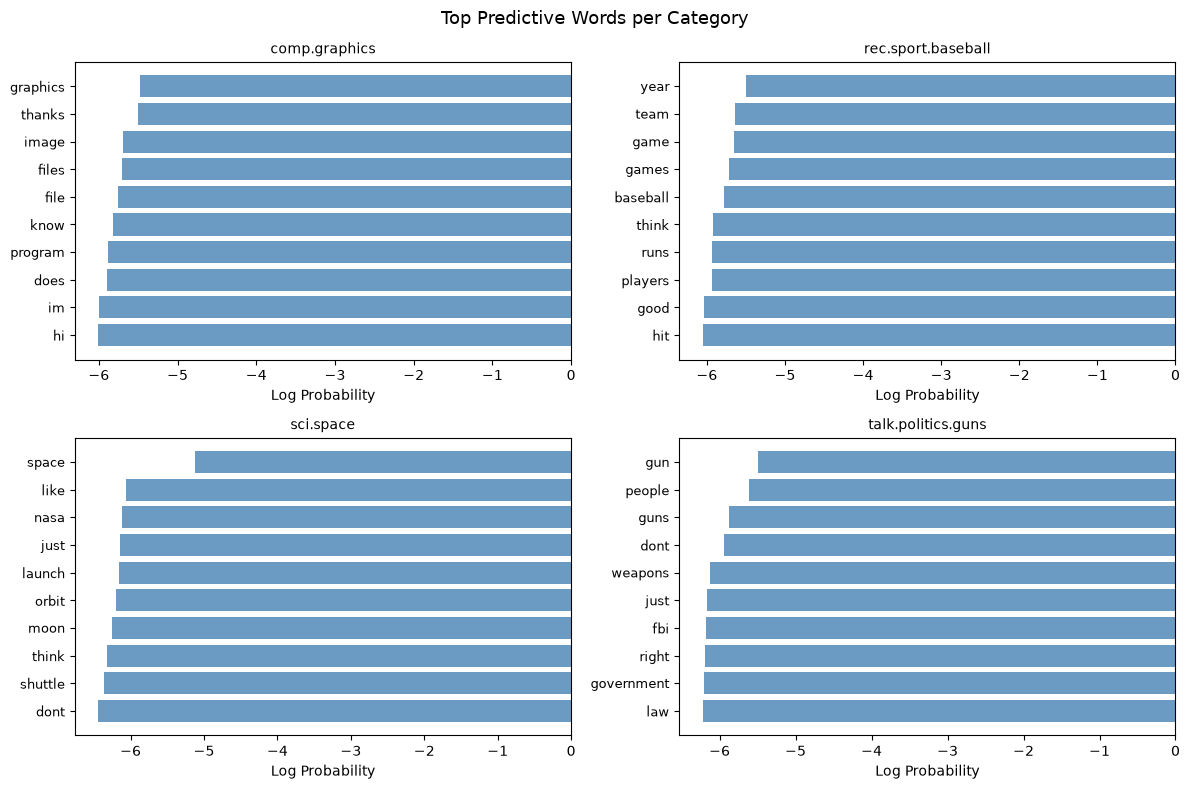

In [6]:
feature_names = vectorizer.get_feature_names_out()
n_top = 10

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, i, cat in zip(axes.flatten(), range(4), train_data.target_names):
    top_idx = np.argsort(nb.feature_log_prob_[i])[-n_top:][::-1]
    top_words = feature_names[top_idx]
    top_scores = nb.feature_log_prob_[i][top_idx]
    
    ax.barh(range(n_top), top_scores[::-1], color='steelblue', alpha=0.8)
    ax.set_yticks(range(n_top))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    ax.set_title(cat, fontsize=10)
    ax.set_xlabel('Log Probability')

plt.suptitle('Top Predictive Words per Category', fontsize=13)
plt.tight_layout()
plt.savefig('task6_top_words.png', dpi=100)
plt.show()

## Summary

- Multinomial Naive Bayes with TF-IDF achieves strong accuracy (typically 90%+) on 4-class newsgroups classification.
- The top predictive words make intuitive sense — 'space', 'nasa', 'orbit' for sci.space; 'gun', 'firearms' for politics.guns etc.
- Removing email headers/footers/quotes is important — otherwise the model cheats by learning author names or signatures.
- Despite the 'naive' independence assumption, this approach is still a solid baseline for text classification tasks.